<a href="https://colab.research.google.com/github/rameshpolaveni2576/python-basics-assignment/blob/main/Decision_Tree_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
from sklearn.tree import DecisionTreeClassifier,plot_tree,export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
df=sns.load_dataset("titanic")


In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


In [6]:
features=["pclass","sex","age","sibsp","parch","fare","embarked"]
target="survived"

In [7]:
data=df[features+[target]].copy()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   sex       891 non-null    object 
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   embarked  889 non-null    object 
 7   survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [9]:
data["age"]=data["age"].fillna(data["age"].median())

In [10]:
data["embarked"]=data["embarked"].fillna(data["embarked"].mode()[0])

In [11]:
data_encoded=pd.get_dummies(data,columns=["embarked","sex"],drop_first=True)

In [12]:
data_encoded=data_encoded.drop_duplicates()

In [15]:
X=data_encoded.drop("survived",axis=1)
y=data_encoded["survived"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
    )


In [14]:
tree_model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)


In [16]:
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

In [17]:
tree_model.get_depth()

4

In [18]:
tree_model.get_n_leaves()

np.int64(12)

In [19]:
tree_model.n_features_in_

8

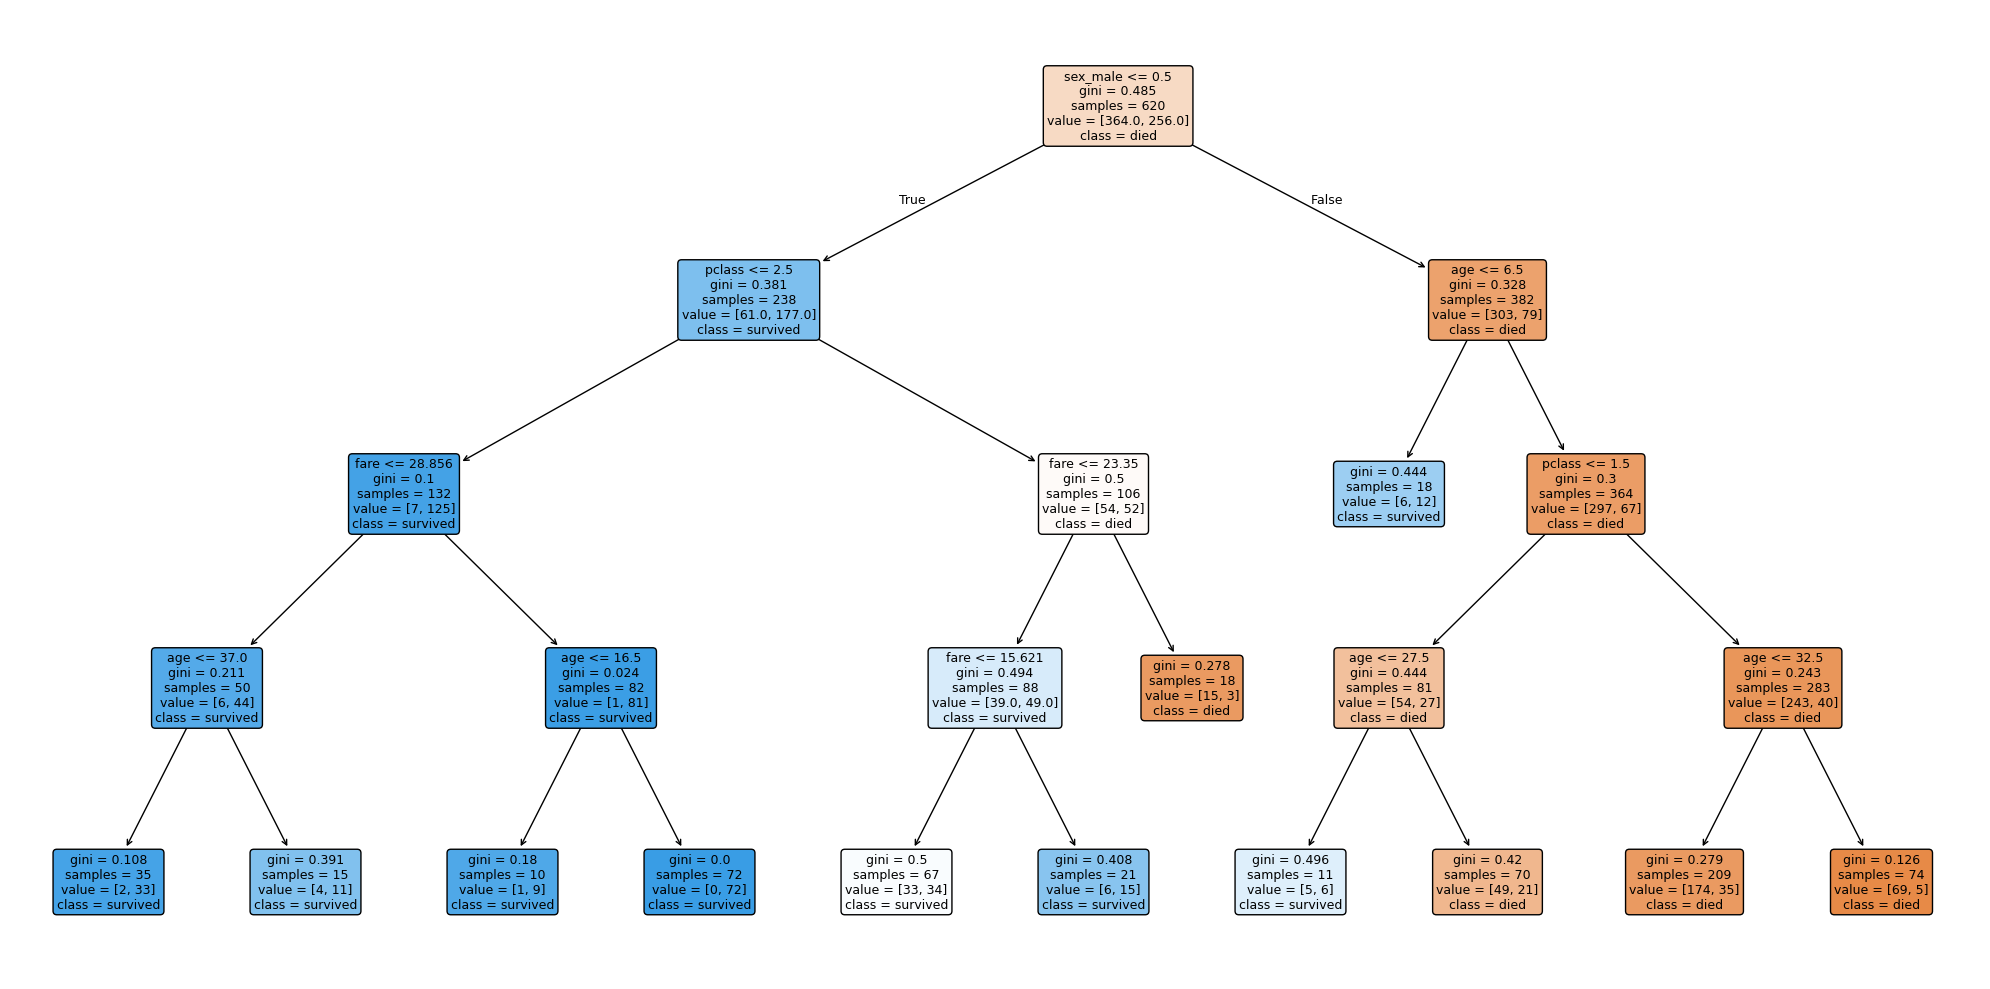

In [20]:
fig, ax=plt.subplots(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.tight_layout()
plt.show()

In [21]:
tree_rules=export_text(tree_model,feature_names=X.columns.tolist())
print(tree_rules)

|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 28.86
|   |   |   |--- age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- fare >  28.86
|   |   |   |--- age <= 16.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  16.50
|   |   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 23.35
|   |   |   |--- fare <= 15.62
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  15.62
|   |   |   |   |--- class: 1
|   |   |--- fare >  23.35
|   |   |   |--- class: 0
|--- sex_male >  0.50
|   |--- age <= 6.50
|   |   |--- class: 1
|   |--- age >  6.50
|   |   |--- pclass <= 1.50
|   |   |   |--- age <= 27.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  27.50
|   |   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- age <= 32.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  32.50
|   |   |   |   |--- class: 0



In [22]:
sample_idx=X_test.index[0]
sample=X_test.loc[sample_idx]

In [23]:
for feature,value in sample.items():
  print(f"{feature}:  {value}")


pclass:  3
age:  24.0
sibsp:  0
parch:  0
fare:  8.85
embarked_Q:  False
embarked_S:  True
sex_male:  False


In [24]:
actual_outcome="survived" if y_test.loc[sample_idx]==1 else "died"

In [25]:
prediction=tree_model.predict(sample.values.reshape(1,-1))
model_prediction="survived" if prediction[0]==1 else "died"

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [26]:
y_pred=tree_model.predict(X_test)
train_accuracy=tree_model.score(X_train,y_train)
test_accuracy=tree_model.score(X_test,y_test)

In [27]:
print(f"{train_accuracy=}")
print(f"{test_accuracy=}")
print(f"{accuracy_score(y_test,y_pred)=}")
print(f"{classification_report(y_test,y_pred)=}")

train_accuracy=0.8048387096774193
test_accuracy=0.7870967741935484
accuracy_score(y_test,y_pred)=0.7870967741935484
classification_report(y_test,y_pred)='              precision    recall  f1-score   support\n\n           0       0.81      0.84      0.82        91\n           1       0.75      0.72      0.74        64\n\n    accuracy                           0.79       155\n   macro avg       0.78      0.78      0.78       155\nweighted avg       0.79      0.79      0.79       155\n'


In [28]:
print(classification_report(y_test,y_pred,target_names=["died","survived"]))

              precision    recall  f1-score   support

        died       0.81      0.84      0.82        91
    survived       0.75      0.72      0.74        64

    accuracy                           0.79       155
   macro avg       0.78      0.78      0.78       155
weighted avg       0.79      0.79      0.79       155



In [29]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["died","survived"])


In [30]:
print(cm)

[[76 15]
 [18 46]]


In [31]:
print(disp)

In [32]:
importance=pd.DataFrame({
    "feature":X.columns,
    "importance":tree_model.feature_importances_
})


In [33]:
importance=importance.sort_values("importance",ascending=False)

In [34]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [35]:
lr_model=LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train_scaled,y_train)
y_pred_lr=lr_model.predict(X_test_scaled)
print(classification_report(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81        91
           1       0.73      0.72      0.72        64

    accuracy                           0.77       155
   macro avg       0.77      0.77      0.77       155
weighted avg       0.77      0.77      0.77       155

[[74 17]
 [18 46]]
